# Plotting Corona virus

Er zijn verschillende websites die visualisaties maken van het corona virus. Een bekende is 

https://gisanddata.maps.arcgis.com/apps/opsdashboard/index.html#/bda7594740fd40299423467b48e9ecf6

Maar hoe wordt die gemaakt? In dit notebook kijken we naar verschillende visualisaties van het virus. Data kun je vinden op 

https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib.ticker import NullFormatter
from matplotlib.dates import MonthLocator, DateFormatter
import geopandas as gpd

## Lees de data

Allereerst lezen we de data. De data is in csv format op het internet. Als we de url opgeven inclusief de naam van het bestand kan pandas dat inlezen. 


In [20]:
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/03-11-2020.csv"
coviddata = pd.read_csv(url)
coviddata.head()

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,Latitude,Longitude
0,Hubei,China,2020-03-11T10:53:02,67773,3046,49134,30.9756,112.2707
1,NaN,Italy,2020-03-11T21:33:02,12462,827,1045,43.0000,12.0000
2,NaN,Iran,2020-03-11T18:52:03,9000,354,2959,32.0000,53.0000
3,NaN,"Korea, South",2020-03-11T21:13:18,7755,60,288,36.0000,128.0000
4,France,France,2020-03-11T22:53:03,2281,48,12,46.2276,2.2137


## Plotten geomap

Let op: In windows in Geo map soms moeilijk te installeren. Sla dit stuk dan over

De data bevat geometrische data (locatie longitude en latitude) en data over aantallen. Dit gaan we gebruiken voor een geop visualisatie met geopandas. De wereldkaart zelf halen we ook uit geopandas

In [21]:
lat = np.array(coviddata['Latitude'])
long = np.array(coviddata['Longitude'])
size = np.array(coviddata['Confirmed'])
zipped = zip(long, lat, size)

In [22]:
countries = gpd.read_file('../data/ne_110m_admin_0_countries.zip')
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


<Axes: >

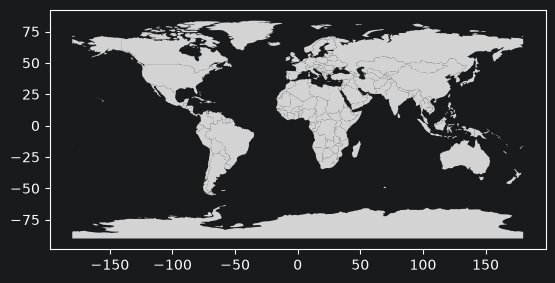

In [23]:
countries.plot(color="lightgrey")

Om de data over elkaar heen te plotten gebruiken we het principe van meerdere objecten op de canvas (figure, ax)

In [24]:
## Inspecteer de data iets meer
coviddata.head()

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,Latitude,Longitude
0,Hubei,China,2020-03-11T10:53:02,67773,3046,49134,30.9756,112.2707
1,NaN,Italy,2020-03-11T21:33:02,12462,827,1045,43.0000,12.0000
2,NaN,Iran,2020-03-11T18:52:03,9000,354,2959,32.0000,53.0000
3,NaN,"Korea, South",2020-03-11T21:13:18,7755,60,288,36.0000,128.0000
4,France,France,2020-03-11T22:53:03,2281,48,12,46.2276,2.2137


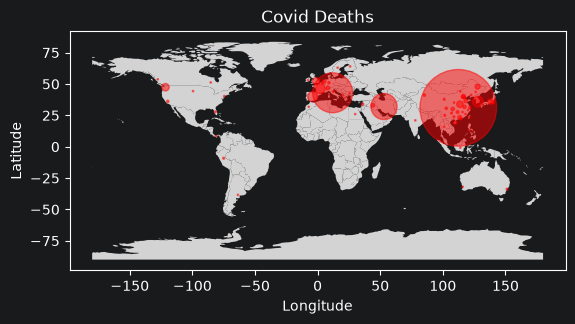

In [27]:
# initialize an axis
fig, ax = plt.subplots()
# plot map on axis

countries.plot(color="lightgrey", ax=ax)
# plot points
data.plot(x="Longitude", y="Latitude", kind="scatter", 
        color = 'red', s="Deaths", alpha=0.5,
        ax=ax, title = "Covid Deaths")
plt.show()# initialize an axis

Dit is natuurlijk een interessante visualisatie maar er is nog veel meer te inspecteren. 

## Opdracht plotjes

maak een violin plot van een variable van 4 landen. Hints: kijk bij https://fennaf.gitbook.io/dataprocessing/data-inspection/melt

In [34]:
## First melt the table to a variable of interest, such as 'Confirmed'.
melted_cases = coviddata.melt(id_vars='Confirmed')
melted_cases.head()  # inspect the new dataframe

,Confirmed,variable,value
0,67773,Province/State,Hubei
1,12462,Province/State,NaN
2,9000,Province/State,NaN
3,7755,Province/State,NaN
4,2281,Province/State,France


In [63]:
## Group by countries
X = melted_cases[melted_cases['variable'] == 'Country/Region']
means = X.groupby('value')['Confirmed'].mean()
stds = X.groupby('value')['Confirmed'].std()

print(means.values)

[1.10000000e+01 1.20000000e+01 2.00000000e+01 1.00000000e+00
 0.00000000e+00 1.90000000e+01 1.00000000e+00 1.60000000e+01
 1.48000000e+02 1.10000000e+01 1.95000000e+02 3.00000000e+00
 9.00000000e+00 3.14000000e+02 1.00000000e+00 2.00000000e+00
 7.00000000e+00 3.80000000e+01 1.10000000e+01 7.00000000e+00
 2.00000000e+00 3.00000000e+00 2.00000000e+00 4.56000000e+01
 2.30000000e+01 2.38002941e+03 9.00000000e+00 1.00000000e+00
 1.30000000e+01 1.00000000e+00 1.90000000e+01 6.96000000e+02
 2.00000000e+00 9.10000000e+01 2.22000000e+02 5.00000000e+00
 1.70000000e+01 6.00000000e+01 1.60000000e+01 1.15000000e+02
 7.61333333e+02 5.00000000e+00 2.40000000e+01 1.90800000e+03
 9.90000000e+01 1.00000000e+00 2.00000000e+00 1.30000000e+01
 8.50000000e+01 6.20000000e+01 3.40000000e+01 9.00000000e+03
 7.10000000e+01 4.30000000e+01 9.00000000e+01 1.24620000e+04
 1.00000000e+00 6.39000000e+02 1.00000000e+00 0.00000000e+00
 0.00000000e+00 7.75500000e+03 7.20000000e+01 1.00000000e+01
 6.10000000e+01 3.000000

IndexError: invalid index to scalar variable.

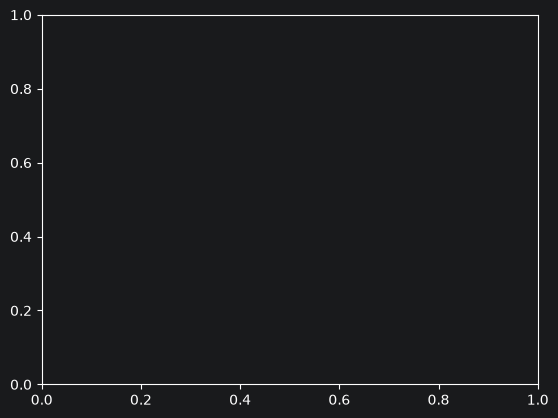

In [66]:
fig, ax = plt.subplots()

ax.violin()

## Time series
Laten we eens naar de time series data kijken

In [8]:
#Allereerst laden we de data

In [9]:
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
data_t = pd.read_csv(url)
data_t.iloc[197:199]


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/26/21,9/27/21,9/28/21,9/29/21,9/30/21,10/1/21,10/2/21,10/3/21,10/4/21,10/5/21
197,NaN,Netherlands,52.1326,5.2913,0,0,0,0,0,0,...,1996498,1997885,1999592,2001347,2003050,2004763,2006421,2008024,2009648,2011530
198,Cook Islands,New Zealand,-21.2367,-159.7777,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1


In [10]:
data_t.index = data_t['Country/Region']
data_t = data_t.drop('Province/State', axis = 1)
data_t = data_t.drop('Country/Region', axis = 1)
data_t = data_t.drop('Lat', axis = 1)
data_t = data_t.drop('Long', axis = 1)
data_t.iloc[197]

1/22/20          0
1/23/20          0
1/24/20          0
1/25/20          0
1/26/20          0
            ...   
10/1/21    2004763
10/2/21    2006421
10/3/21    2008024
10/4/21    2009648
10/5/21    2011530
Name: Netherlands, Length: 623, dtype: int64

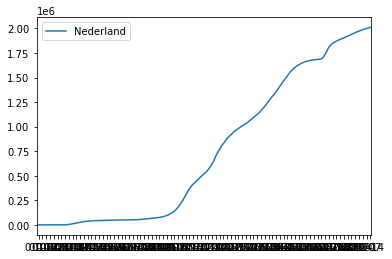

In [11]:
# dan laden we x en y
import matplotlib.pyplot as plt
import warnings

from matplotlib.ticker import NullFormatter
from matplotlib.dates import DateFormatter

x = data_t.columns.values.tolist()
nl= np.array(data_t.iloc[197])
plt.plot(x, nl, label="Nederland")
plt.legend()

ax = plt.gca()
ax.set_xlim([1.0, len(x)])

import matplotlib.dates as mdates
days = mdates.WeekdayLocator()
daysFmt = mdates.DateFormatter('%m-%d')
ax.xaxis.set_major_locator(days)
ax.xaxis.set_major_formatter(daysFmt)

plt.show()

# Opdracht
Maak de labels van de time series mooier. Plot ook Sweden

In [12]:
#your code here